In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetV2B0

import numpy as np
import matplotlib.pyplot as plt
import os

In [9]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30

dataset_dir = "C:/Users\Sujal Pal\OneDrive\Desktop/New Deep Learning\CNN/archive (1)"

In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 4260 files belonging to 2 classes.
Using 3408 files for training.
Found 4260 files belonging to 2 classes.
Using 852 files for validation.
Classes: ['Anemic', 'Non-anemic']


In [11]:
class_counts = {name: len(os.listdir(os.path.join(dataset_dir, name))) for name in class_names}
total = sum(class_counts.values())

class_weights = {
    0: total / (2 * class_counts[class_names[0]]),
    1: total / (2 * class_counts[class_names[1]])
}

print("Class Weights:", class_weights)

Class Weights: {0: 0.8313817330210773, 1: 1.254416961130742}


In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)

In [14]:
base_model = EfficientNetV2B0(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [15]:
model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LOWER LR
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3)

checkpoint = ModelCheckpoint("best_efficientnet.h5", save_best_only=True)

In [18]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4991 - loss: 0.8269 - precision: 0.4009 - recall: 0.4955

107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 186ms/step - accuracy: 0.5053 - loss: 0.8050 - precision: 0.3968 - recall: 0.5019 - val_accuracy: 0.4237 - val_loss: 0.7345 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5082 - loss: 0.7805 - precision: 0.3997 - recall: 0.5077

107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.5062 - loss: 0.7802 - precision: 0.3991 - recall: 0.5116 - val_accuracy: 0.4237 - val_loss: 0.7287 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.4947 - loss: 0.7818 - precision: 0.3897 - recall: 0.5086 - val_accuracy: 0.4237 - val_loss: 0.7287 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.4910 - loss: 0.7674 - precision: 0.3720 - recall: 0.5046

107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.5003 - loss: 0.7607 - precision: 0.3918 - recall: 0.4959 - val_accuracy: 0.4237 - val_loss: 0.7007 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.4862 - loss: 0.7646 - precision: 0.3803 - recall: 0.4921 - val_accuracy: 0.4237 - val_loss: 0.7123 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.4965 - loss: 0.7636 - precision: 0.3887 - recall: 0.4951 - val_accuracy: 0.4237 - val_loss: 0.7763 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.5076 - loss: 0.7558 - precision: 0.3981 - recall: 0.4981 - val_accuracy: 0.4237 - val_loss: 0.7123 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 118m

107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.4918 - loss: 0.7582 - precision: 0.3854 - recall: 0.4966 - val_accuracy: 0.4237 - val_loss: 0.6967 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 3.0000e-06
Epoch 9/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.5029 - loss: 0.7532 - precision: 0.3958 - recall: 0.5071 - val_accuracy: 0.4237 - val_loss: 0.6976 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 3.0000e-06
Epoch 10/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.5067 - loss: 0.7493 - precision: 0.3993 - recall: 0.5101 - val_accuracy: 0.4237 - val_loss: 0.7020 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 3.0000e-06
Epoch 11/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.5003 - loss: 0.7528 - precision: 0.3890 - recall: 0.4794 - val_accuracy: 0.4237 - val_loss: 0.7068 - val_precision: 0.4237 - val_recall: 1.0000 - learning_rate: 3.0000e-06
Epoch 12/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 

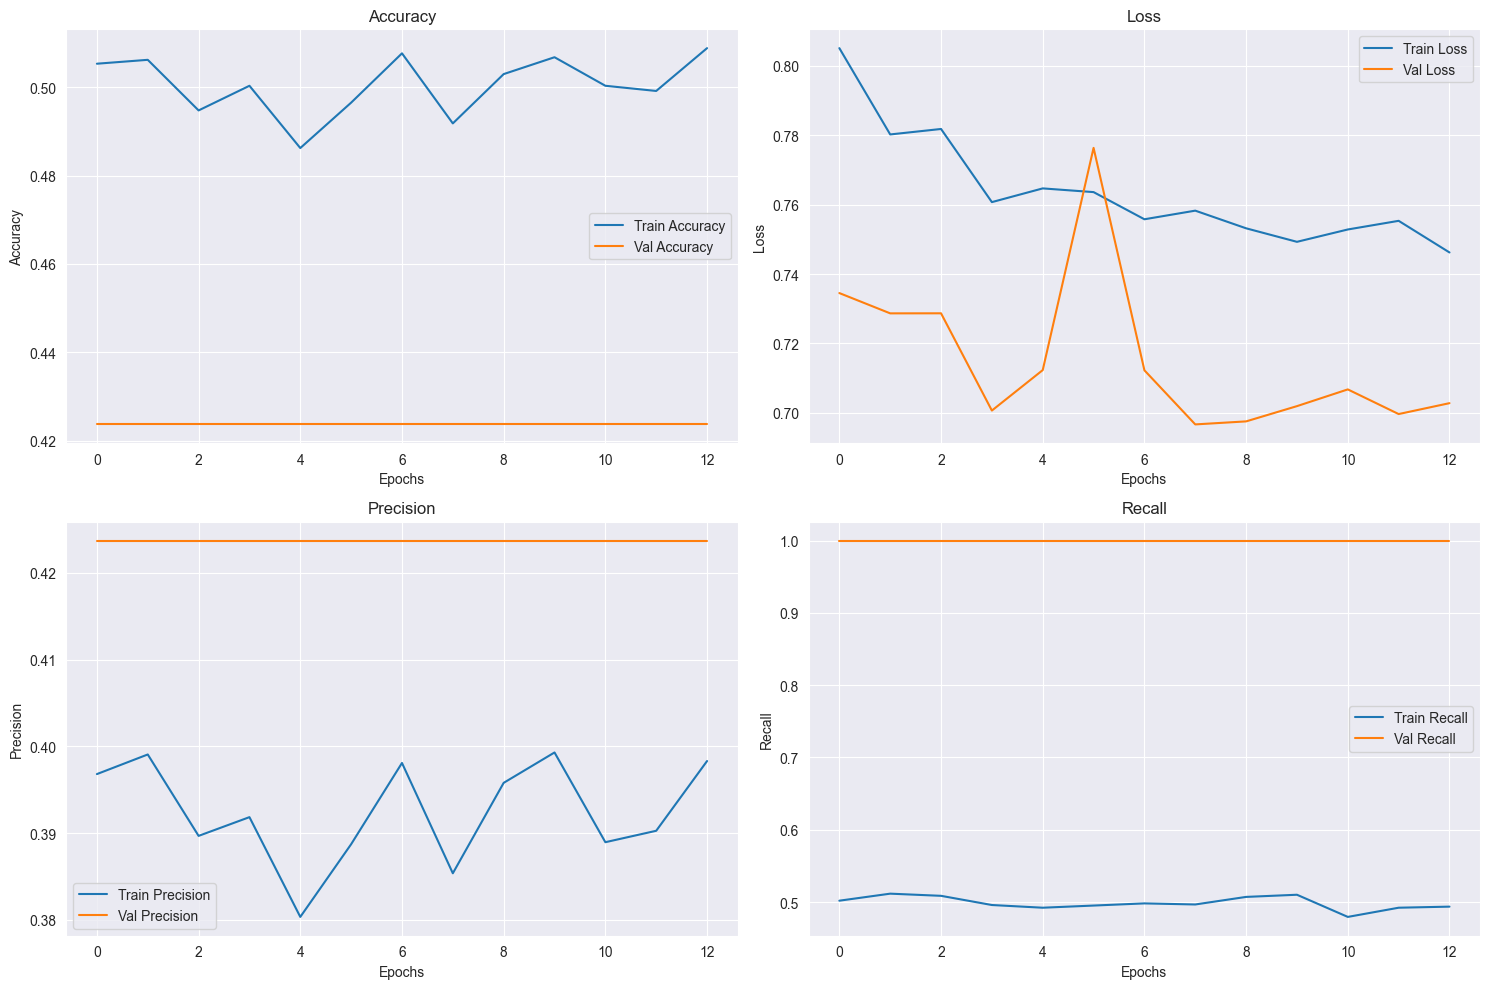

In [19]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(15,10))

    # Accuracy
    plt.subplot(2,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(2,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Precision
    plt.subplot(2,2,3)
    plt.plot(history.history['precision'], label='Train Precision')
    plt.plot(history.history['val_precision'], label='Val Precision')
    plt.title('Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()

    # Recall
    plt.subplot(2,2,4)
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.title('Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

C:\Users\Sujal Pal\OneDrive\Desktop\New Deep Learning\CNN\.venv1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sujal Pal\OneDrive\Desktop\New Deep Learning\CNN\.venv1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sujal Pal\OneDrive\Desktop\New Deep Learning\CNN\.venv1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

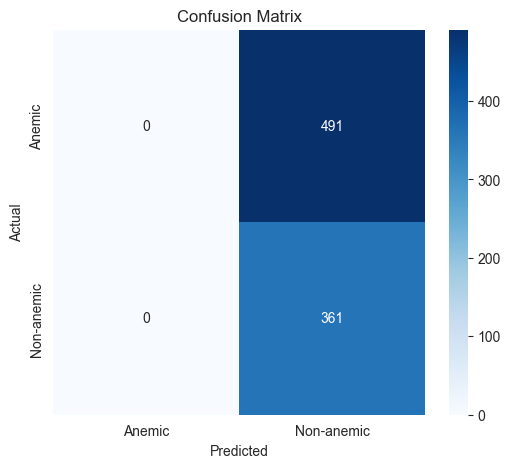

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

# Get predictions
for images, labels in val_dataset:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ===============================
# 1. CONFUSION MATRIX (NUMERIC)
# ===============================
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# ===============================
# 2. CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# ===============================
# 3. CONFUSION MATRIX (GRAPH)
# ===============================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()